# Project 3 Relationship Between Listing Price and Availability in NYC Airbnb Data 2019

- **Dataset(s) to be used:** https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data
- **Analysis question:** Does higher Airbnb listing availability (number of days available per year) correlate with lower prices?
And if so, does this relationship differ by neighborhood group (Manhattan, Brooklyn, Queens, Bronx, Staten Island)?
- **Columns that will (likely) be used:**
  - `price`
  - `longitude`, `latitude`
  - `neighborhood`
  - etc.
- **Hypothesis:** 
 Listings with higher availability tend to have lower prices, because high availability may signal lower demand. I further expect this negative relationship to be strongest in Manhattan, where pricing pressure and competition for guests or tourism are highest.

## Data Cleaning and Processing

In [3]:
# Load the Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
# Read data rows and columns
df.shape

(48895, 16)

In [6]:
# 2.3. Missing values overview

df.isna().sum().sort_values(ascending=False)

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
id                                    0
host_id                               0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [7]:
# Make a working copy
df_clean = df.copy()

# Filter out zero and extremely high prices
df_clean = df_clean[df_clean["price"] > 0]
df_clean = df_clean[df_clean["price"] <= 1000]

# Filter out extreme minimum_nights (very long stays)
df_clean = df_clean[df_clean["minimum_nights"] <= 60]

# Keep availability within valid range
df_clean = df_clean[
    (df_clean["availability_365"] >= 0) & (df_clean["availability_365"] <= 365)
]

# Reset index
df_clean = df_clean.reset_index(drop=True)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

df_clean[["price", "availability_365", "minimum_nights"]].describe()


Original shape: (48895, 16)
Cleaned shape: (48330, 16)


,price,availability_365,minimum_nights
count,48330.00000,48330.000000,48330.000000
mean,141.33205,111.908856,5.878750
std,116.82308,131.204949,8.873137
min,10.00000,0.000000,1.000000
25%,69.00000,0.000000,1.000000
50%,105.00000,44.000000,2.000000
75%,175.00000,224.000000,5.000000
max,1000.00000,365.000000,60.000000


In [8]:
# Categorize availability_365 into five bins
availability_bins = [0, 30, 90, 180, 365]
availability_labels = ["0–30", "31–90", "91–180", "181–365"]

df_clean = df_clean.copy()  # 防止 SettingWithCopyWarning
df_clean["availability_bin"] = pd.cut(
    df_clean["availability_365"],
    bins=availability_bins,
    labels=availability_labels,
    include_lowest=True,
)

df_clean["availability_bin"].value_counts().sort_index()

availability_bin
0–30       22661
31–90       6377
91–180      5208
181–365    14084
Name: count, dtype: int64

In [9]:
# Group by neighbourhood_group and room_type, then review the results.
group_stats_room = (
    df_clean.groupby(["neighbourhood_group", "room_type"])
    .agg(
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        mean_availability=("availability_365", "mean"),
        count=("id", "count"),
    )
    .reset_index()
)

group_stats_room.head()


,neighbourhood_group,room_type,mean_price,median_price,mean_availability,count
0,Bronx,Entire home/apt,128.732432,100.0,157.481081,370
1,Bronx,Private room,63.180556,53.5,170.794753,648
2,Bronx,Shared room,60.389831,40.0,153.610169,59
3,Brooklyn,Entire home/apt,168.634268,145.0,96.434162,9455
4,Brooklyn,Private room,72.904081,65.0,99.494986,10071


## Data Visualization

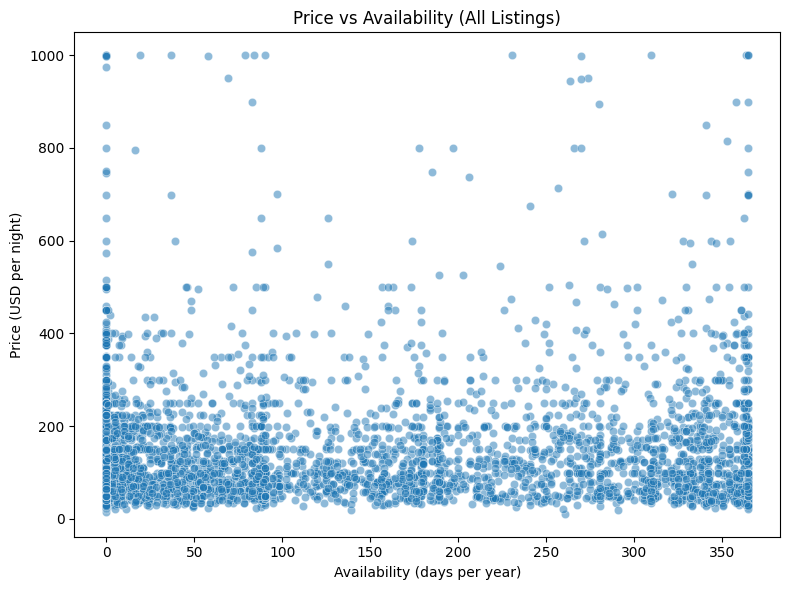

In [10]:
# Draw a scatter plot for price vs availability_365
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean.sample(min(5000, len(df_clean))),
    x="availability_365",
    y="price",
    alpha=0.5,
)
plt.title("Price vs Availability (All Listings)")
plt.xlabel("Availability (days per year)")
plt.ylabel("Price (USD per night)")
plt.tight_layout()
plt.show()

### Interpretation 1: An overall picture to start

The scatter plot above shows the relationship between nightly price and listing availability (number of days available per year). Each point represents one Airbnb listing in New York City.

The pattern looks fairly **similar** across all availability levels:

- Low-priced listings (under \$200) appear across all availability ranges, from 0 to 365 days.
- High-priced listings (above \$500) also appear **at both low and high availability**.
- No visible downward slope is present; if anything, there are still many expensive listings with high availability.

To sum up, this indicates that the relationship between availability and price, if it exists, is **weak and not easily observable** in the aggregate dataset. Further breakdowns by neighborhood or room type is necessary to understand more nuanced patterns. And since the overall picture is blurred, it is not very optimistic to get a positive result for our hypothesis...

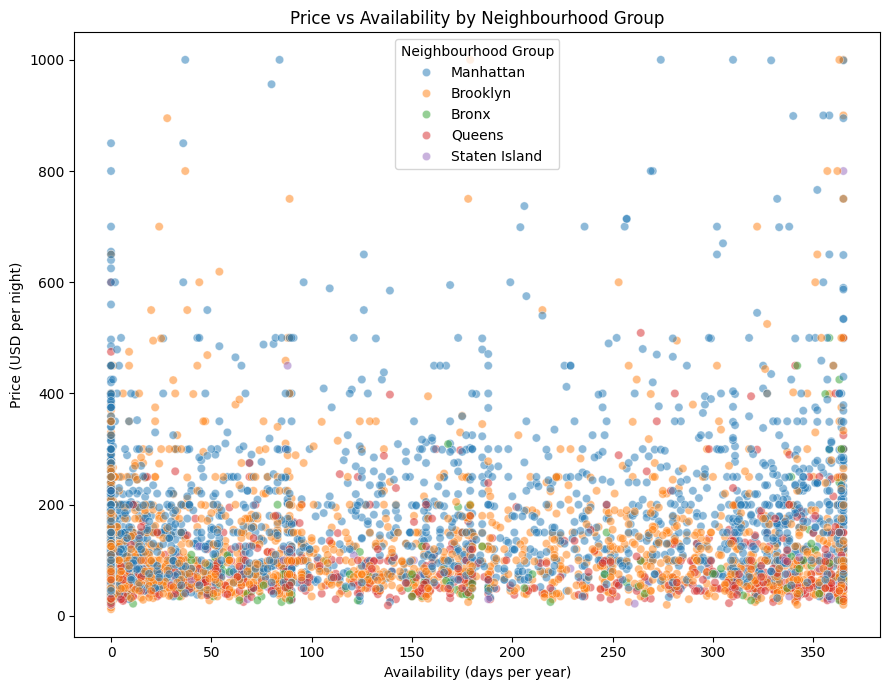

In [13]:
# Now color by neighbourhood_group, further discuss the relationship between price and availability_365.
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_clean.sample(min(6000, len(df_clean))),
    x="availability_365",
    y="price",
    hue="neighbourhood_group",
    alpha=0.5,
)
plt.title("Price vs Availability by Neighbourhood Group")
plt.xlabel("Availability (days per year)")
plt.ylabel("Price (USD per night)")
plt.legend(title="Neighbourhood Group")
plt.tight_layout()
plt.show()


### Interpretation 2
#### Manhattan (blue points)
- Manhattan listings tend to occupy the **upper price range**, regardless of availability.  
- Even among listings available for over 300 days, prices often remain high.  
- This **contradicts** the hypothesis: **high availability does not imply low demand or low price** in Manhattan.

#### Brooklyn (orange points)
- Brooklyn shows the widest price variation but again does not display a negative relationship.  
- High-availability listings can still be moderately expensive, and low-availability listings are not necessarily more expensive.

#### Queens, Bronx, and Staten Island
- These boroughs cluster more tightly at the lower end of the price scale.  
- However, availability does not differentiate them:  
  cheap listings appear across the entire availability range.

## Conclusion

**1. Baseline pattern**  
The overall scatter plot shows that price does not decline as availability increases. Listings with both high and low prices appear across the entire availability range, indicating no meaningful negative relationship in the dataset as a whole.

**2. Regarding the hypothesis: Is the negative relationship strongest in Manhattan?**  
When neighborhood groups are added, Manhattan clearly has higher overall prices, but the price–availability pattern remains flat within the borough. High-availability listings in Manhattan are not cheaper than low-availability listings, and expensive listings appear at all availability levels. **The relationship is visually similar across other boroughs.**

**3. Final interpretation**  
Since the overall trend is flat and Manhattan does not exhibit a stronger negative pattern compared to other boroughs, the visual evidence does not support our hypothesis. Sadly we have to disprove it and confirm that no supportive evidence could prove our assumptions. Availability does not appear to meaningfully shape price in any borough, including Manhattan. But at lease we can still tell that NYC is really an expensive city...

## To look a bit deeper...

In [ ]:
# The map provides a spatial perspective on the relationship between price and availability.
# Colors represent listing prices, while circle size reflects availability.
import folium
from branca.colormap import LinearColormap

# Center of NYC
nyc_center = [40.7128, -74.0060]

# Sample some points so the map is not too heavy
sample_df = df_clean.sample(min(3000, len(df_clean)), random_state=0)

# Create base map
m_map = folium.Map(location=nyc_center, zoom_start=11, tiles="CartoDB positron")

# Colormap for price (blue = cheap, red = expensive)
colormap = LinearColormap(
    colors=["blue", "green", "yellow", "orange", "red"],
    vmin=sample_df["price"].min(),
    vmax=sample_df["price"].max(),
    caption="Price (USD per night)",
)
colormap.add_to(m_map)

# Add circle markers: color = price, radius = availability
for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2
        + 4
        * row["availability_365"]
        / 365,  # more availability → slightly bigger circle
        stroke=False,
        fill=True,
        fill_opacity=0.6,
        fill_color=colormap(row["price"]),
    ).add_to(m_map)

# Add a simple title
title_html = """
     <h3 align="center" style="font-size:16px">
         NYC Airbnb Map: Price (color) and Availability (circle size)
     </h3>
     """
m_map.get_root().html.add_child(folium.Element(title_html))

m_map


### Map analysis of Price and Availability
 As expected, the highest-priced listings (yellow to red) cluster in Manhattan, with additional pockets in parts of Brooklyn. In contrast, the outer boroughs and areas farther from the city center show predominantly lower-priced listings.

However, large circles, representing listings with high availability, appear in both low-price (blue/green) and high-price (yellow/red) regions. In Manhattan, many highly available listings remain expensive, suggesting that high availability does not signal lower demand or reduced pricing. **This suggests that location strongly influences price, but availability does not exhibit the hypothesized negative relationship, even in the borough like Manhattan where pricing pressure is high.**

Now I would officially say that the hypythesis is not proved. 